# Sonuç Analizi

Bu notebook, `src/run_30_models.py` (30 model benchmark), `scripts/build_final_test_summary.py`
(final test özeti) ve `scripts/shap_analysis.py` (SHAP + permütasyon önem analizi) tarafından
üretilen `results/tables/` ve `results/plots/` altındaki kanonik sonuçları okuyup özetler.

Burada hiçbir model yeniden eğitilmiyor, sadece daha önce üretilmiş CSV/PNG dosyaları okunuyor.
Detaylı metodoloji ve tartışma için bkz. proje raporu ve `HANDOFF_UPDATE.md`.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().parent
TABLES = PROJECT_ROOT / "results" / "tables"
PLOTS = PROJECT_ROOT / "results" / "plots"
SHAP_DIR = PROJECT_ROOT / "results" / "figures" / "shap"

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

## 30 model karşılaştırması (5 katlı CV)

Her hedef için ayrı bir leaderboard var (`leaderboard_{target}.csv`), 5 katlı CV validation
RMSE'sine göre sıralanmış (önce RMSE artan, sonra R^2 azalan). İlk 5 model:

In [2]:
leaderboard_cols = [
    "rank", "model", "cv_validation_rmse_mean", "cv_validation_rmse_std",
    "cv_validation_r2_mean", "validation_rmse", "validation_r2",
]

for target in ["density", "pld", "lcd"]:
    leaderboard = pd.read_csv(TABLES / f"leaderboard_{target}.csv")
    print(f"--- {target} ---")
    display(leaderboard[leaderboard_cols].head(5))

--- density ---


,rank,model,cv_validation_rmse_mean,cv_validation_rmse_std,cv_validation_r2_mean,validation_rmse,validation_r2
0,1,lgbm_regressor,0.268351,0.006195,0.823323,0.264051,0.822777
1,2,hist_gradient_boosting,0.277017,0.006690,0.811735,0.276077,0.806267
2,3,extra_trees,0.278480,0.008989,0.809695,0.271552,0.812565
3,4,xgb_regressor,0.279203,0.006212,0.808695,0.274628,0.808295
4,5,voting_regressor,0.279883,0.007661,0.807698,0.274713,0.808177


--- pld ---


,rank,model,cv_validation_rmse_mean,cv_validation_rmse_std,cv_validation_r2_mean,validation_rmse,validation_r2
0,1,extra_trees,1.392520,0.116326,0.838375,1.411366,0.845328
1,2,random_forest,1.417707,0.118686,0.832630,1.484936,0.828783
2,3,lgbm_regressor,1.429918,0.096049,0.830203,1.469614,0.832298
3,4,xgb_regressor,1.437498,0.115066,0.828075,1.460189,0.834442
4,5,hist_gradient_boosting,1.449843,0.103273,0.825557,1.504013,0.824355


--- lcd ---


,rank,model,cv_validation_rmse_mean,cv_validation_rmse_std,cv_validation_r2_mean,validation_rmse,validation_r2
0,1,extra_trees,1.522330,0.092225,0.864764,1.484731,0.874975
1,2,random_forest,1.559327,0.111580,0.858094,1.584693,0.857574
2,3,xgb_regressor,1.561945,0.103415,0.857811,1.569778,0.860242
3,4,lgbm_regressor,1.568423,0.077642,0.856695,1.586603,0.857230
4,5,hist_gradient_boosting,1.603133,0.080570,0.850259,1.622850,0.850632


## Kazanan modeller ve final test sonucu

Her hedef için en iyi CV RMSE'sine sahip model (yukarıdaki leaderboard'un 1. sırası),
train+validation birleşimi üzerinde yeniden eğitilip test setinde **tek seferlik**
değerlendirildi (`src/train.py::run_final_test`). Test seti bu aşamaya kadar hiç
kullanılmadı.

In [3]:
final_test_summary = pd.read_csv(TABLES / "final_test_summary.csv")
display(final_test_summary[[
    "target", "model", "test_n", "test_mae", "test_rmse", "test_r2", "test_normalized_rmse",
]])

,target,model,test_n,test_mae,test_rmse,test_r2,test_normalized_rmse
0,density,lgbm_regressor,2603,0.187577,0.257124,0.819803,0.403878
1,lcd,extra_trees,2603,0.876586,1.433301,0.867168,0.344797
2,pld,extra_trees,2603,0.790868,1.321797,0.831653,0.377604


## CV ortalaması vs. test seti

Model seçimi test setine hiç bakmadan (CV + holdout validation) yapıldı. Aşağıdaki tablo,
bu seçimin daha önce hiç görülmemiş test verisine ne kadar iyi genellediğini gösteriyor.

In [4]:
comparison = pd.read_csv(TABLES / "cv_vs_test_comparison.csv")
display(comparison)

,target,model,cv_rmse_mean,cv_rmse_std,test_rmse,rmse_diff_test_minus_cv,rmse_diff_pct,cv_r2_mean,test_r2,r2_diff_test_minus_cv
0,density,lgbm_regressor,0.268351,0.006195,0.257124,-0.011227,-4.183624,0.823323,0.819803,-0.003520
1,pld,extra_trees,1.392520,0.116326,1.321797,-0.070723,-5.078796,0.838375,0.831653,-0.006721
2,lcd,extra_trees,1.522330,0.092225,1.433301,-0.089029,-5.848213,0.864764,0.867168,0.002403


Üç hedefte de test RMSE'si CV ortalamasından biraz daha iyi çıkıyor (fark CV standart
sapmasının ötesine geçmiyor), R^2 farkları da hepsinde 0.01'in altında. Bu, 30 model
arasından en iyisini seçmenin validation setine aşırı uymadığının, CV tahmininin test
verisine güvenilir şekilde genellediğinin bir işareti.

## Test seti parity grafikleri

density / lgbm_regressor


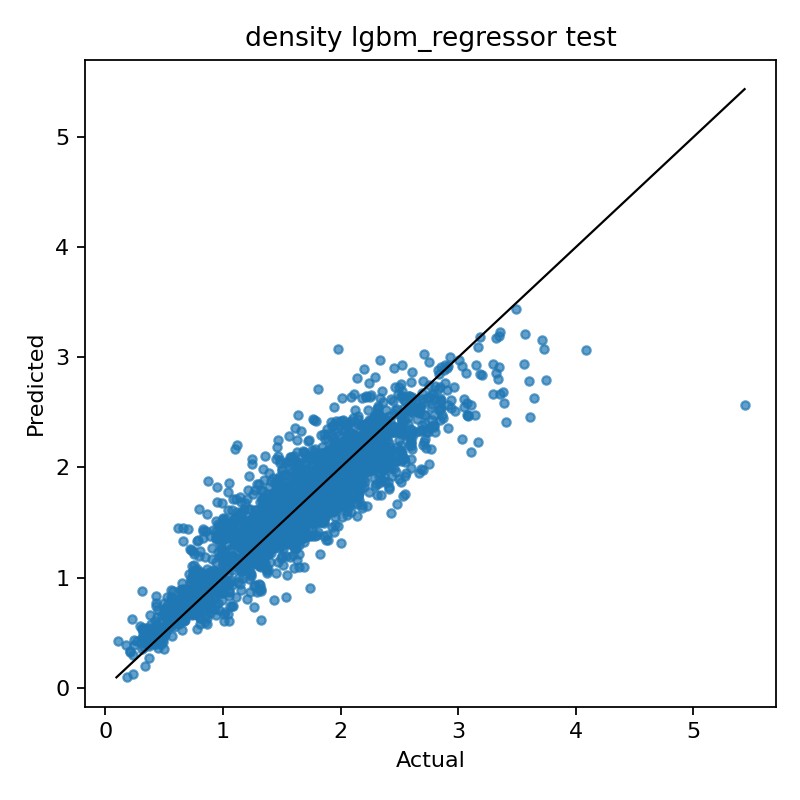

lcd / extra_trees


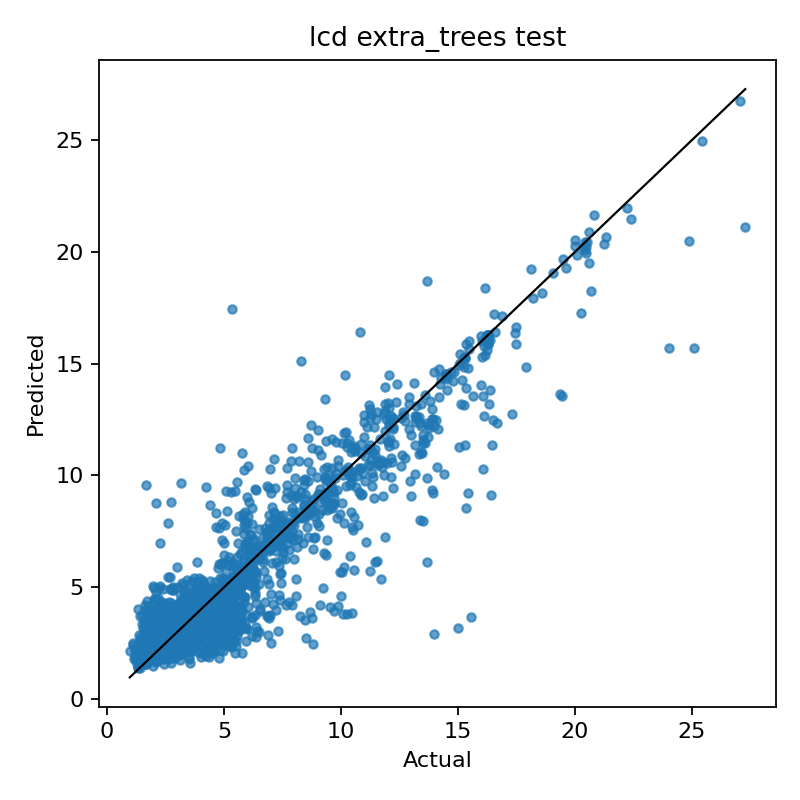

pld / extra_trees


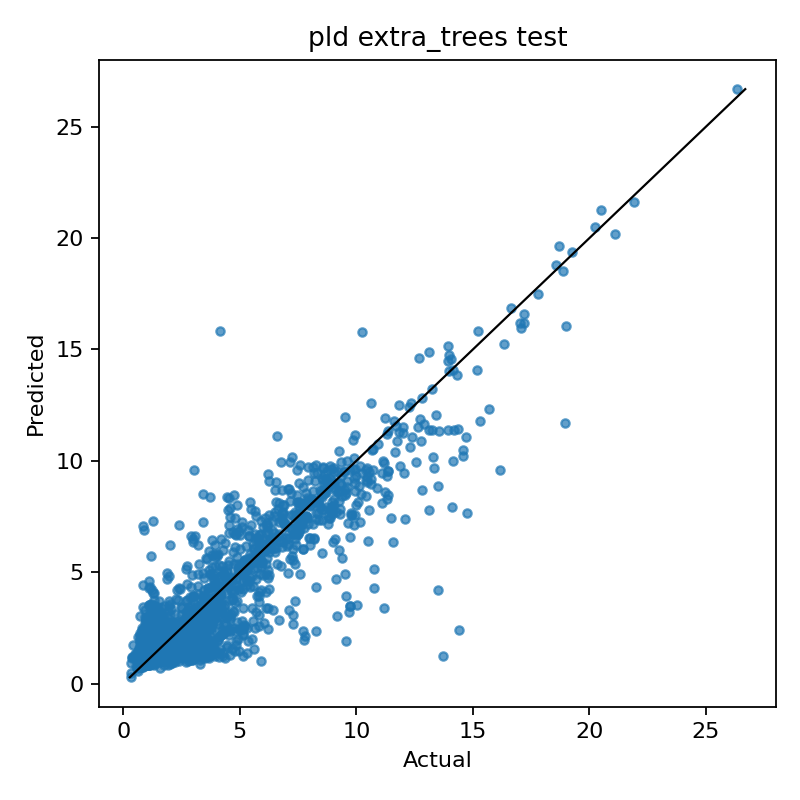

In [5]:
for _, row in final_test_summary.iterrows():
    path = PLOTS / f"{row['target']}_{row['model']}_test_parity.png"
    print(f"{row['target']} / {row['model']}")
    display(Image(filename=str(path)))

## SHAP ve permütasyon tabanlı özellik grubu önemi

Kazanan 3 model için SHAP (TreeExplainer) ve permütasyon tabanlı grup önemi karşılaştırıldı,
örneklem validation setinden alındı -- test setine SHAP aşamasında da dokunulmadı
(bkz. `scripts/shap_analysis.py`).

In [6]:
shap_summary = pd.read_csv(TABLES / "shap_group_summary.csv")
perm_summary = pd.read_csv(TABLES / "permutation_group_importance.csv")

comparison_table = shap_summary.merge(
    perm_summary[["target", "model", "feature_group", "pct_of_total_rmse_increase"]],
    on=["target", "model", "feature_group"],
).rename(columns={
    "pct_of_total_abs_shap": "shap_pct",
    "pct_of_total_rmse_increase": "permutation_pct",
})[["target", "model", "feature_group", "shap_pct", "permutation_pct"]]

display(comparison_table.round(1))

,target,model,feature_group,shap_pct,permutation_pct
0,density,lgbm_regressor,linker_selfies,47.3,43.1
1,density,lgbm_regressor,node_selfies,33.3,40.5
2,density,lgbm_regressor,point_group,9.9,7.0
3,density,lgbm_regressor,topology,9.4,9.4
4,density,lgbm_regressor,topology_missing,0.0,0.0
5,pld,extra_trees,linker_selfies,42.1,28.4
6,pld,extra_trees,node_selfies,25.9,23.9
7,pld,extra_trees,point_group,16.2,22.6
8,pld,extra_trees,topology,13.7,22.8
9,pld,extra_trees,topology_missing,2.1,2.2


İki yöntem de her üç hedefte `linker_selfies` ve `node_selfies` gruplarının en baskın iki
grup olduğu konusunda hemfikir. En büyük fark pld/lcd'de `topology` ve `point_group`
gruplarında: permütasyon testi bu iki gruba SHAP'e göre belirgin şekilde daha fazla pay
veriyor, çünkü permütasyon bir grubun tamamen karıştırılmasının toplam RMSE'ye etkisini
ölçüyor (özellikler arası etkileşimleri de içine katarak), SHAP ise ortalama |değer| ile
bireysel tahmine yapılan marjinal katkıyı ölçüyor.

### Örnek SHAP grafikleri (density / lgbm_regressor)

pld ve lcd için aynı grafikler (bar, beeswarm, waterfall) `results/figures/shap/` altında.

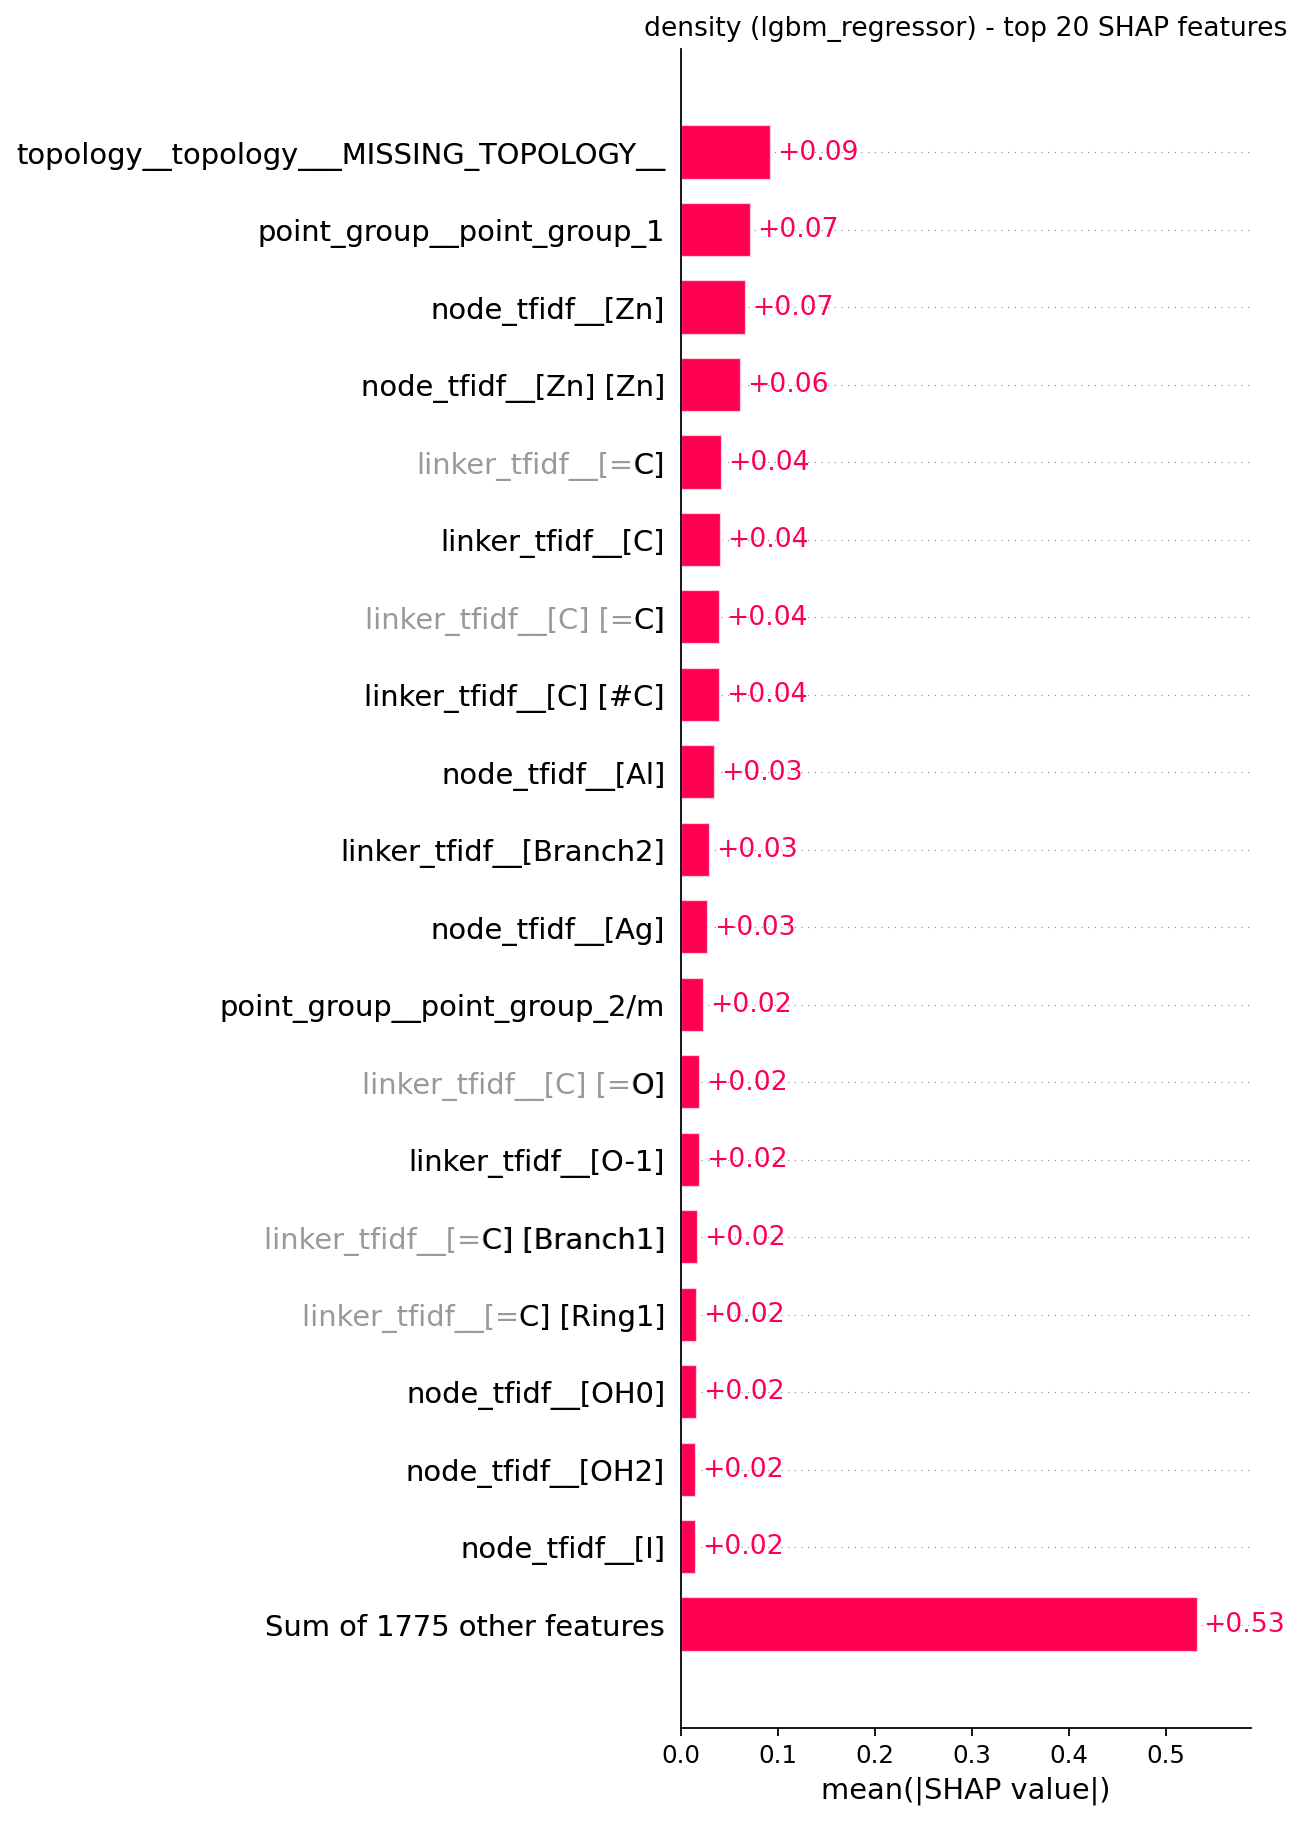

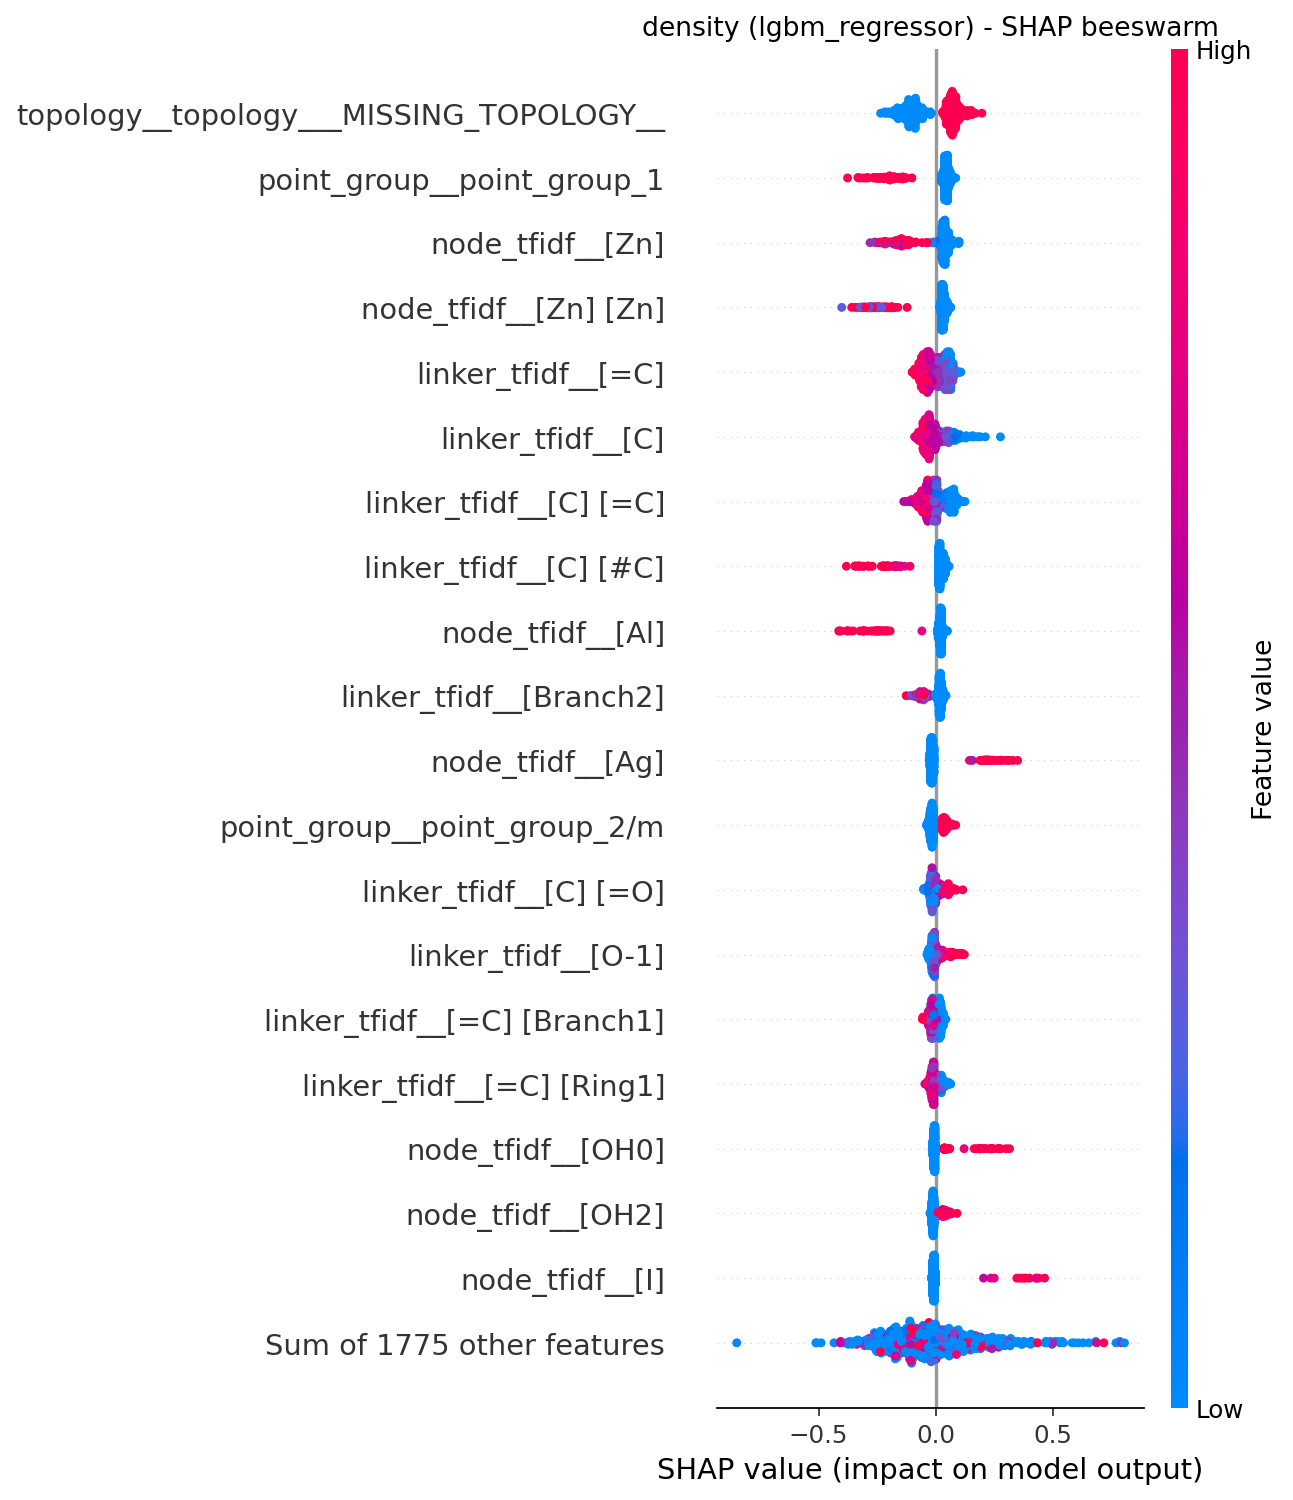

In [7]:
display(Image(filename=str(SHAP_DIR / "density_lgbm_regressor_bar.png")))
display(Image(filename=str(SHAP_DIR / "density_lgbm_regressor_beeswarm.png")))

## Genel model sıralaması (3 hedef ortalaması)

Bir modelin 3 hedefteki ortalama sırası -- hangi model ailesinin genel olarak en tutarlı
performansı verdiğini gösteriyor.

In [8]:
overall_ranking = pd.read_csv(TABLES / "overall_model_ranking.csv")
display(overall_ranking.head(10))

,model,target_count,average_rank,average_normalized_rmse,average_r2
0,extra_trees,3,2.000000,0.401087,0.837611
1,lgbm_regressor,3,2.666667,0.403109,0.836740
2,random_forest,3,3.666667,0.408428,0.831770
3,xgb_regressor,3,4.000000,0.408979,0.831527
4,hist_gradient_boosting,3,4.333333,0.412341,0.829184
5,selfies_transformer,3,4.666667,0.419724,0.822926
6,voting_regressor,3,6.666667,0.425427,0.818118
7,catboost_regressor,3,10.666667,0.454091,0.792436
8,bagging,3,11.000000,0.456187,0.789161
9,poisson_regressor,3,11.666667,0.469300,0.779094


## Özet

- Üç hedefte de ağaç tabanlı ensemble modeller (ExtraTrees, LightGBM) kazandı; doğrusal
  modeller (özellikle SGDRegressor) 1794 boyutlu seyrek TF-IDF uzayında numerik olarak
  ıraksadı (bkz. `HANDOFF_UPDATE.md` bölüm 1.1).
- Final test RMSE'si her üç hedefte de 5 katlı CV ortalamasıyla tutarlı (fark ~%4-6, CV
  std'sinin ötesine geçmiyor) -- model seçim protokolü test setine sızıntı yapmadı.
- linker_selfies ve node_selfies özellik grupları SHAP ve permütasyon önem testlerinde
  bağımsız olarak en baskın iki grup olarak çıktı; bu, moleküler SELFIES token'larının
  yapısal özellikler için en bilgilendirici girdi olduğunu gösteriyor.